# EuroSAT Satellite Image Classification

**Capstone Project – Deep Learning with PyTorch**

**Student Name:** ____________________  
**Student ID:** ____________________  
**Course:** ____________________  
**Date:** ____________________

---

## Project Overview

The goal of this project is to classify satellite images into 10 land-use classes using deep learning.

This notebook includes:

- Downloading and exploring the EuroSAT dataset
- Image resizing, normalization, and data augmentation
- Stratified train, validation, and test splitting
- A custom Convolutional Neural Network (CNN)
- Hyperparameter experiments
- Early stopping
- A ResNet18 transfer-learning comparison
- Accuracy, precision, recall, and F1-score
- Confusion matrix and prediction examples
- Misclassification analysis
- Saving the final model and experiment results

## 1. Dataset Description

EuroSAT is an RGB satellite image dataset. In Torchvision, it can be loaded with
`torchvision.datasets.EuroSAT`.

The dataset has 10 land-use classes:

1. Annual Crop
2. Forest
3. Herbaceous Vegetation
4. Highway
5. Industrial
6. Pasture
7. Permanent Crop
8. Residential
9. River
10. Sea or Lake

This is a useful real-world classification problem because satellite image
classification can support land monitoring, environmental studies, and urban planning.

**Official references**

- EuroSAT dataset loader: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.EuroSAT.html
- Torchvision transforms: https://docs.pytorch.org/tutorials/beginner/basics/transforms_tutorial.html
- PyTorch transfer learning: https://docs.pytorch.org/tutorials/beginner/transfer_learning_tutorial.html

## 2. Before Running

The first run downloads the EuroSAT dataset and, if ResNet18 is enabled,
downloads pretrained model weights.

Install the required packages if they are not already installed:

```bash
pip install torch torchvision scikit-learn pandas matplotlib
```

For a quick test, set `FAST_MODE = True`.  
For the final submitted results, use `FAST_MODE = False`.

In [1]:
# Import libraries
import os
import random
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    ConfusionMatrixDisplay
)

from IPython.display import display

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.6.0+cu126
CUDA available: True


## 3. Reproducibility and Project Settings

A random seed is used so the data split and model initialization are more reproducible.

`FAST_MODE` is useful for checking whether all cells work. It uses fewer images and
fewer epochs. It should be changed to `False` for the final experiment.

In [2]:
# Reproducibility
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # These settings improve reproducibility.
    # They may slightly reduce training speed.
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Main project settings
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./eurosat_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 64
FAST_MODE = False

# FAST_MODE only uses a smaller balanced subset for code testing.
MAX_IMAGES_PER_CLASS = 300 if FAST_MODE else None

TUNING_EPOCHS = 3 if FAST_MODE else 8
FINAL_EPOCHS = 5 if FAST_MODE else 20
RESNET_EPOCHS = 3 if FAST_MODE else 8

EARLY_STOPPING_PATIENCE = 3
NUM_WORKERS = 0   # 0 is stable on Windows and Jupyter
RUN_RESNET18 = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("FAST_MODE:", FAST_MODE)

Device: cuda
FAST_MODE: False


## 4. Image Preprocessing and Data Augmentation

Training images use random augmentation:

- Random resized crop
- Horizontal flip
- Vertical flip
- Rotation
- Small brightness and contrast changes

These transformations are suitable for satellite images because the land-use class
normally does not change when the image is rotated or flipped.

Validation and test images do not use random augmentation. They only use resizing,
tensor conversion, and normalization.

In [3]:
# ImageNet normalization values are used for both the custom CNN and ResNet18.
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00),
        ratio=(0.90, 1.10)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
])

print(train_transform)

Compose(
    RandomResizedCrop(size=(64, 64), scale=(0.8, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.9, 1.1), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


## 5. Download and Inspect the Dataset

The dataset is first loaded without a transform so its labels can be used to create
a stratified split. A stratified split keeps approximately the same class proportions
in the training, validation, and test sets.

In [4]:
# Download the complete dataset.
base_dataset = datasets.EuroSAT(
    root=DATA_DIR,
    download=True
)

class_names = base_dataset.classes
targets = np.array(base_dataset.targets)
all_indices = np.arange(len(base_dataset))

print("Total images:", len(base_dataset))
print("Number of classes:", len(class_names))
print("Classes:")
for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

100%|█████████████████████████████████████████████████████████████████████████████| 94.3M/94.3M [00:01<00:00, 49.6MB/s]


Total images: 27000
Number of classes: 10
Classes:
0: AnnualCrop
1: Forest
2: HerbaceousVegetation
3: Highway
4: Industrial
5: Pasture
6: PermanentCrop
7: Residential
8: River
9: SeaLake


In [5]:
# Optional balanced subset for FAST_MODE.
# When MAX_IMAGES_PER_CLASS is None, all dataset images are used.
if MAX_IMAGES_PER_CLASS is not None:
    selected_indices = []

    for class_id in range(len(class_names)):
        class_indices = all_indices[targets == class_id]
        rng = np.random.default_rng(SEED)
        rng.shuffle(class_indices)
        selected_indices.extend(class_indices[:MAX_IMAGES_PER_CLASS])

    selected_indices = np.array(selected_indices)
    selected_targets = targets[selected_indices]
else:
    selected_indices = all_indices
    selected_targets = targets

print("Images selected for this run:", len(selected_indices))

Images selected for this run: 27000


,image_count
AnnualCrop,3000
Forest,3000
HerbaceousVegetation,3000
Highway,2500
Industrial,2500
Pasture,2000
PermanentCrop,2500
Residential,3000
River,2500
SeaLake,3000


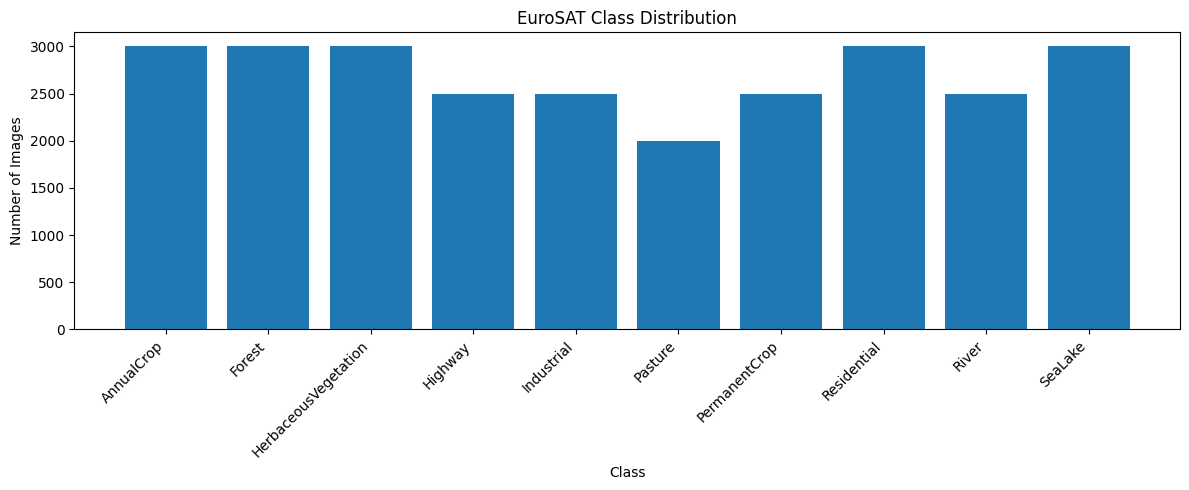

In [6]:
# Display the class distribution.
class_distribution = pd.Series(
    selected_targets
).value_counts().sort_index()

class_distribution.index = [
    class_names[index] for index in class_distribution.index
]

distribution_df = class_distribution.rename("image_count").to_frame()
display(distribution_df)

plt.figure(figsize=(12, 5))
plt.bar(distribution_df.index, distribution_df["image_count"])
plt.title("EuroSAT Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 6. Train, Validation, and Test Split

The selected data is divided into:

- 70% training
- 15% validation
- 15% test

The test set is held out and is not used for hyperparameter selection.

In [7]:
# First split: 70% training and 30% temporary data.
train_indices, temp_indices = train_test_split(
    selected_indices,
    test_size=0.30,
    random_state=SEED,
    stratify=targets[selected_indices]
)

# Second split: divide temporary data equally into validation and test sets.
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=targets[temp_indices]
)

print("Training images:", len(train_indices))
print("Validation images:", len(val_indices))
print("Test images:", len(test_indices))
print("Total:", len(train_indices) + len(val_indices) + len(test_indices))

Training images: 18900
Validation images: 4050
Test images: 4050
Total: 27000


In [8]:
# Create separate dataset objects because training and evaluation use different transforms.
train_dataset_all = datasets.EuroSAT(
    root=DATA_DIR,
    transform=train_transform,
    download=False
)

evaluation_dataset_all = datasets.EuroSAT(
    root=DATA_DIR,
    transform=evaluation_transform,
    download=False
)

train_dataset = Subset(train_dataset_all, train_indices)
val_dataset = Subset(evaluation_dataset_all, val_indices)
test_dataset = Subset(evaluation_dataset_all, test_indices)

def split_class_counts(indices, split_name):
    counts = pd.Series(targets[indices]).value_counts().sort_index()
    return pd.Series(
        counts.values,
        index=[class_names[i] for i in counts.index],
        name=split_name
    )

split_distribution_df = pd.concat([
    split_class_counts(train_indices, "Train"),
    split_class_counts(val_indices, "Validation"),
    split_class_counts(test_indices, "Test")
], axis=1)

display(split_distribution_df)

,Train,Validation,Test
AnnualCrop,2100,450,450
Forest,2100,450,450
HerbaceousVegetation,2100,450,450
Highway,1750,375,375
Industrial,1750,375,375
Pasture,1400,300,300
PermanentCrop,1750,375,375
Residential,2100,450,450
River,1750,375,375
SeaLake,2100,450,450


In [9]:
# DataLoader function.
# A different batch size can be used for each hyperparameter experiment.
def make_loaders(batch_size):
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, test_loader

# Temporary loaders for checking data.
train_loader, val_loader, test_loader = make_loaders(batch_size=32)

images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: torch.Size([32, 3, 64, 64])
Label batch shape: torch.Size([32])


## 7. Display Augmented Training Images

The images below are randomly augmented examples. Their appearance may change each
time the cell is run.

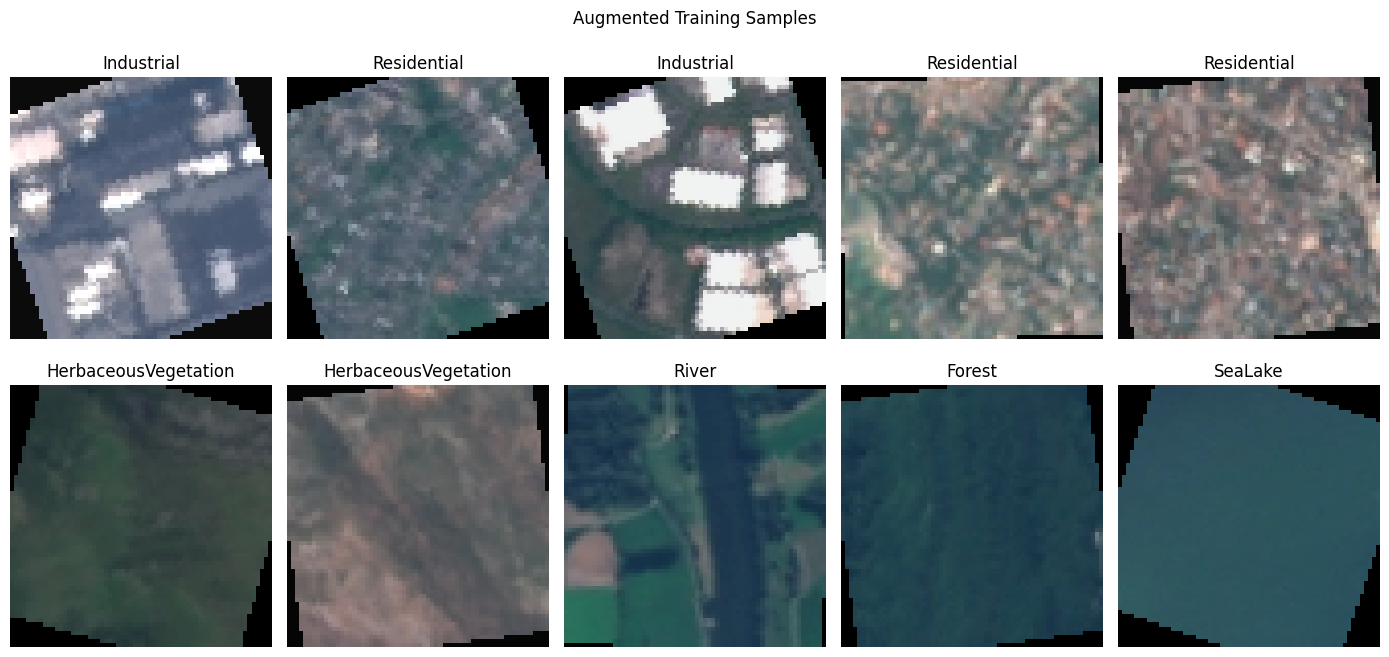

In [10]:
def denormalize_image(image_tensor):
    mean = torch.tensor(NORMALIZE_MEAN).view(3, 1, 1)
    std = torch.tensor(NORMALIZE_STD).view(3, 1, 1)
    image_tensor = image_tensor.cpu() * std + mean
    return torch.clamp(image_tensor, 0, 1)

images, labels = next(iter(train_loader))

plt.figure(figsize=(14, 7))
for i in range(min(10, len(images))):
    plt.subplot(2, 5, i + 1)
    image = denormalize_image(images[i]).permute(1, 2, 0).numpy()
    plt.imshow(image)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.suptitle("Augmented Training Samples")
plt.tight_layout()
plt.show()

## 8. Custom CNN Architecture

The first model is a custom CNN trained from scratch.

Architecture:

1. Convolution block with 32 filters
2. Convolution block with 64 filters
3. Convolution block with 128 filters
4. Convolution block with 256 filters
5. Adaptive average pooling
6. Fully connected layer with dropout
7. Output layer with 10 classes

Batch normalization and dropout are used to reduce overfitting.

In [11]:
class EuroSATCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


def count_trainable_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

sample_model = EuroSATCNN(
    num_classes=len(class_names),
    dropout_rate=0.3
).to(device)

print(sample_model)
print("Trainable parameters:", f"{count_trainable_parameters(sample_model):,}")

# Check one forward pass.
sample_output = sample_model(images[:4].to(device))
print("Output shape:", sample_output.shape)

EuroSATCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

## 9. Training and Validation Functions

Cross-entropy loss is used because this is a multiclass classification problem.

Early stopping watches validation loss. If validation loss does not improve for a
selected number of epochs, training stops and the best model weights are restored.

In [12]:
def run_one_epoch(model, data_loader, criterion, optimizer=None):
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_examples = 0

    for batch_images, batch_labels in data_loader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        if is_training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_training):
            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)

            if is_training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * batch_images.size(0)
        predictions = outputs.argmax(dim=1)
        correct_predictions += (predictions == batch_labels).sum().item()
        total_examples += batch_labels.size(0)

    epoch_loss = running_loss / total_examples
    epoch_accuracy = correct_predictions / total_examples

    return epoch_loss, epoch_accuracy


def train_model(
    model,
    train_loader,
    val_loader,
    learning_rate,
    max_epochs,
    patience=3
):
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        filter(lambda parameter: parameter.requires_grad, model.parameters()),
        lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": []
    }

    best_val_loss = float("inf")
    best_val_accuracy = 0.0
    best_epoch = 0
    best_model_state = copy.deepcopy(model.state_dict())
    epochs_without_improvement = 0

    start_time = time.time()

    for epoch in range(1, max_epochs + 1):
        train_loss, train_accuracy = run_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_accuracy = run_one_epoch(
            model,
            val_loader,
            criterion,
            optimizer=None
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Epoch {epoch:02d}/{max_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_accuracy = val_accuracy
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_model_state)
    training_time = time.time() - start_time

    summary = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_accuracy,
        "training_time_seconds": training_time
    }

    return model, history, summary

In [13]:
def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], marker="o", label="Training Loss")
    plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        epochs,
        history["train_accuracy"],
        marker="o",
        label="Training Accuracy"
    )
    plt.plot(
        epochs,
        history["val_accuracy"],
        marker="o",
        label="Validation Accuracy"
    )
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

## 10. Hyperparameter Tuning

Three small experiments are used to compare:

- Learning rate
- Batch size
- Dropout rate

The validation set is used to select the best setting. The test set is not used
during this step.

In [14]:
experiment_configs = [
    {
        "experiment": "Experiment 1",
        "learning_rate": 0.001,
        "batch_size": 32,
        "dropout_rate": 0.30
    },
    {
        "experiment": "Experiment 2",
        "learning_rate": 0.0005,
        "batch_size": 32,
        "dropout_rate": 0.30
    },
    {
        "experiment": "Experiment 3",
        "learning_rate": 0.001,
        "batch_size": 64,
        "dropout_rate": 0.50
    }
]

display(pd.DataFrame(experiment_configs))

,experiment,learning_rate,batch_size,dropout_rate
0,Experiment 1,0.0010,32,0.3
1,Experiment 2,0.0005,32,0.3
2,Experiment 3,0.0010,64,0.5


In [15]:
experiment_results = []

for config in experiment_configs:
    print("\n" + "=" * 80)
    print(config["experiment"])
    print(config)
    print("=" * 80)

    set_seed(SEED)

    experiment_train_loader, experiment_val_loader, _ = make_loaders(
        batch_size=config["batch_size"]
    )

    experiment_model = EuroSATCNN(
        num_classes=len(class_names),
        dropout_rate=config["dropout_rate"]
    ).to(device)

    experiment_model, experiment_history, experiment_summary = train_model(
        model=experiment_model,
        train_loader=experiment_train_loader,
        val_loader=experiment_val_loader,
        learning_rate=config["learning_rate"],
        max_epochs=TUNING_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE
    )

    experiment_results.append({
        **config,
        **experiment_summary
    })

results_df = pd.DataFrame(experiment_results)
results_df = results_df.sort_values(
    "best_val_accuracy",
    ascending=False
).reset_index(drop=True)

display(results_df)

results_path = OUTPUT_DIR / "hyperparameter_results.csv"
results_df.to_csv(results_path, index=False)
print("Saved:", results_path)


Experiment 1
{'experiment': 'Experiment 1', 'learning_rate': 0.001, 'batch_size': 32, 'dropout_rate': 0.3}
Epoch 01/8 | Train Loss: 1.1399 | Train Acc: 0.5869 | Val Loss: 1.2263 | Val Acc: 0.6128
Epoch 02/8 | Train Loss: 0.8594 | Train Acc: 0.6935 | Val Loss: 0.7012 | Val Acc: 0.7459
Epoch 03/8 | Train Loss: 0.7609 | Train Acc: 0.7268 | Val Loss: 0.6705 | Val Acc: 0.7565
Epoch 04/8 | Train Loss: 0.7005 | Train Acc: 0.7554 | Val Loss: 0.5020 | Val Acc: 0.8326
Epoch 05/8 | Train Loss: 0.6376 | Train Acc: 0.7767 | Val Loss: 0.5762 | Val Acc: 0.7933
Epoch 06/8 | Train Loss: 0.5913 | Train Acc: 0.7943 | Val Loss: 0.4664 | Val Acc: 0.8286
Epoch 07/8 | Train Loss: 0.5462 | Train Acc: 0.8149 | Val Loss: 0.4315 | Val Acc: 0.8435
Epoch 08/8 | Train Loss: 0.5009 | Train Acc: 0.8277 | Val Loss: 0.4771 | Val Acc: 0.8425

Experiment 2
{'experiment': 'Experiment 2', 'learning_rate': 0.0005, 'batch_size': 32, 'dropout_rate': 0.3}
Epoch 01/8 | Train Loss: 1.1326 | Train Acc: 0.5912 | Val Loss: 1.0156 

,experiment,learning_rate,batch_size,dropout_rate,best_epoch,best_val_loss,best_val_accuracy,training_time_seconds
0,Experiment 1,0.0010,32,0.3,7,0.431488,0.843457,528.524997
1,Experiment 2,0.0005,32,0.3,7,0.461577,0.834568,272.835204
2,Experiment 3,0.0010,64,0.5,3,0.610635,0.786667,201.960621


Saved: eurosat_outputs\hyperparameter_results.csv


### Hyperparameter Interpretation

After running the cell above, write a short explanation here.

Example structure:

> Experiment ___ produced the highest validation accuracy. Its learning rate was
> ___, batch size was ___, and dropout rate was ___. Compared with the other
> experiments, this setting provided a better balance between learning speed and
> model generalization.

## 11. Train the Final Custom CNN

The best hyperparameter setting is selected using validation accuracy. A new model
is then trained with this setting for more epochs.

Selected learning rate: 0.001
Selected batch size: 32
Selected dropout rate: 0.3
Epoch 01/20 | Train Loss: 1.1399 | Train Acc: 0.5869 | Val Loss: 1.2263 | Val Acc: 0.6128
Epoch 02/20 | Train Loss: 0.8594 | Train Acc: 0.6935 | Val Loss: 0.7012 | Val Acc: 0.7459
Epoch 03/20 | Train Loss: 0.7609 | Train Acc: 0.7268 | Val Loss: 0.6705 | Val Acc: 0.7565
Epoch 04/20 | Train Loss: 0.7005 | Train Acc: 0.7554 | Val Loss: 0.5020 | Val Acc: 0.8326
Epoch 05/20 | Train Loss: 0.6376 | Train Acc: 0.7767 | Val Loss: 0.5762 | Val Acc: 0.7933
Epoch 06/20 | Train Loss: 0.5913 | Train Acc: 0.7943 | Val Loss: 0.4664 | Val Acc: 0.8286
Epoch 07/20 | Train Loss: 0.5462 | Train Acc: 0.8149 | Val Loss: 0.4315 | Val Acc: 0.8435
Epoch 08/20 | Train Loss: 0.5009 | Train Acc: 0.8277 | Val Loss: 0.4771 | Val Acc: 0.8425
Epoch 09/20 | Train Loss: 0.4729 | Train Acc: 0.8379 | Val Loss: 0.3833 | Val Acc: 0.8672
Epoch 10/20 | Train Loss: 0.4464 | Train Acc: 0.8463 | Val Loss: 0.3859 | Val Acc: 0.8615
Epoch 11/20 | Train

,best_epoch,best_val_loss,best_val_accuracy,training_time_seconds
0,13,0.237493,0.913333,544.200769


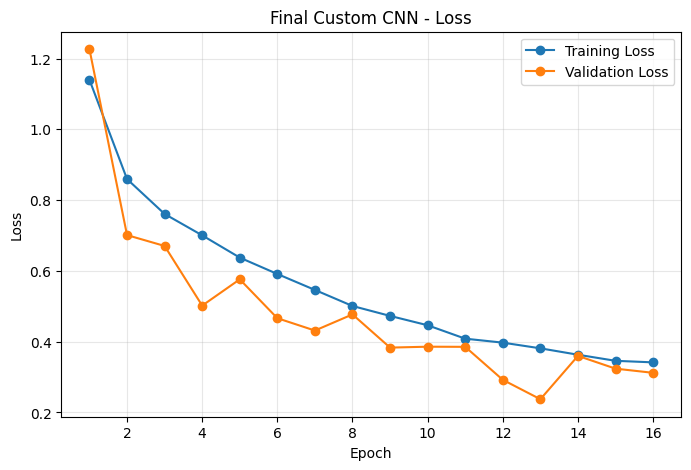

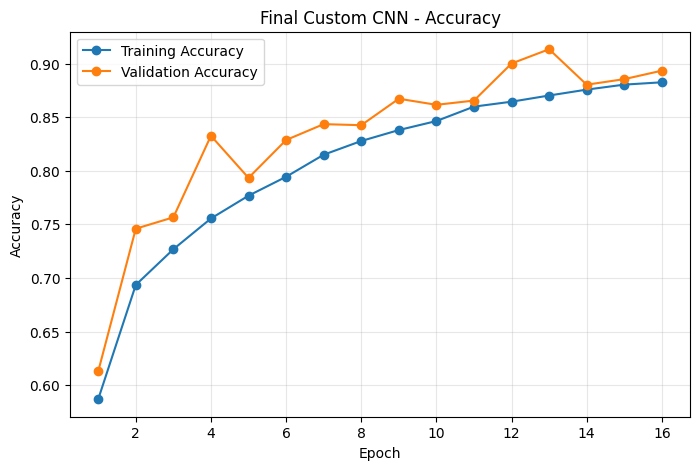

In [16]:
best_config = results_df.iloc[0]

best_learning_rate = float(best_config["learning_rate"])
best_batch_size = int(best_config["batch_size"])
best_dropout_rate = float(best_config["dropout_rate"])

print("Selected learning rate:", best_learning_rate)
print("Selected batch size:", best_batch_size)
print("Selected dropout rate:", best_dropout_rate)

final_train_loader, final_val_loader, final_test_loader = make_loaders(
    batch_size=best_batch_size
)

set_seed(SEED)

final_cnn = EuroSATCNN(
    num_classes=len(class_names),
    dropout_rate=best_dropout_rate
).to(device)

final_cnn, final_cnn_history, final_cnn_summary = train_model(
    model=final_cnn,
    train_loader=final_train_loader,
    val_loader=final_val_loader,
    learning_rate=best_learning_rate,
    max_epochs=FINAL_EPOCHS,
    patience=EARLY_STOPPING_PATIENCE
)

print("\nFinal CNN summary:")
display(pd.DataFrame([final_cnn_summary]))

plot_training_history(
    final_cnn_history,
    title="Final Custom CNN"
)

In [17]:
# Save the final custom CNN.
custom_cnn_path = OUTPUT_DIR / "eurosat_custom_cnn.pth"

torch.save({
    "model_name": "EuroSATCNN",
    "model_state_dict": final_cnn.state_dict(),
    "class_names": class_names,
    "image_size": IMAGE_SIZE,
    "normalization_mean": NORMALIZE_MEAN,
    "normalization_std": NORMALIZE_STD,
    "best_hyperparameters": {
        "learning_rate": best_learning_rate,
        "batch_size": best_batch_size,
        "dropout_rate": best_dropout_rate
    },
    "training_summary": final_cnn_summary
}, custom_cnn_path)

print("Saved:", custom_cnn_path)

Saved: eurosat_outputs\eurosat_custom_cnn.pth


## 12. Optional Model Comparison: ResNet18 Transfer Learning

The second model uses a ResNet18 pretrained on ImageNet.

To keep training time reasonable:

- The pretrained feature layers are frozen.
- Only the final classification layer is trained.
- The final layer is changed to produce 10 EuroSAT classes.

This provides a comparison between a CNN trained from scratch and transfer learning.

ResNet18 trainable parameters: 5,130
Epoch 01/8 | Train Loss: 1.0205 | Train Acc: 0.6653 | Val Loss: 0.9019 | Val Acc: 0.7205
Epoch 02/8 | Train Loss: 0.7832 | Train Acc: 0.7416 | Val Loss: 0.8447 | Val Acc: 0.7415
Epoch 03/8 | Train Loss: 0.7537 | Train Acc: 0.7456 | Val Loss: 0.7972 | Val Acc: 0.7605
Epoch 04/8 | Train Loss: 0.7525 | Train Acc: 0.7476 | Val Loss: 0.7594 | Val Acc: 0.7546
Epoch 05/8 | Train Loss: 0.7428 | Train Acc: 0.7503 | Val Loss: 0.7834 | Val Acc: 0.7568
Epoch 06/8 | Train Loss: 0.7283 | Train Acc: 0.7532 | Val Loss: 0.7318 | Val Acc: 0.7736
Epoch 07/8 | Train Loss: 0.7292 | Train Acc: 0.7546 | Val Loss: 0.7430 | Val Acc: 0.7721
Epoch 08/8 | Train Loss: 0.7189 | Train Acc: 0.7546 | Val Loss: 0.7478 | Val Acc: 0.7632


,best_epoch,best_val_loss,best_val_accuracy,training_time_seconds
0,6,0.731761,0.77358,285.64846


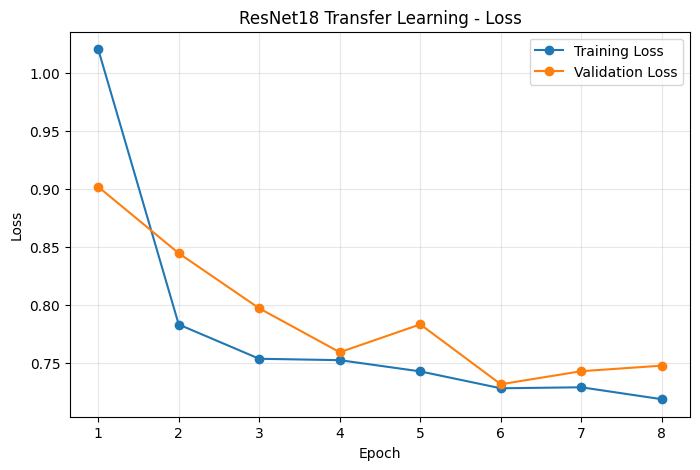

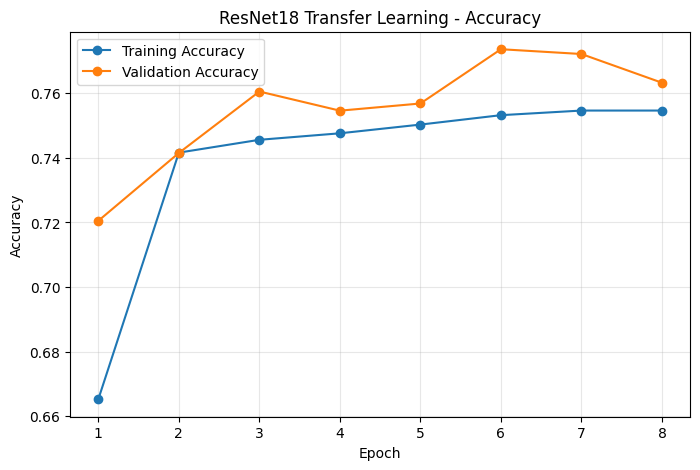

Saved: eurosat_outputs\eurosat_resnet18.pth


In [18]:
def create_resnet18(num_classes):
    try:
        weights = models.ResNet18_Weights.DEFAULT
        model = models.resnet18(weights=weights)
    except AttributeError:
        # Compatibility with older Torchvision versions.
        model = models.resnet18(pretrained=True)

    # Freeze pretrained feature layers.
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Replace the final classification layer.
    input_features = model.fc.in_features
    model.fc = nn.Linear(input_features, num_classes)

    return model


resnet18_model = None
resnet18_history = None
resnet18_summary = None

if RUN_RESNET18:
    set_seed(SEED)

    resnet18_model = create_resnet18(
        num_classes=len(class_names)
    ).to(device)

    print("ResNet18 trainable parameters:",
          f"{count_trainable_parameters(resnet18_model):,}")

    resnet18_model, resnet18_history, resnet18_summary = train_model(
        model=resnet18_model,
        train_loader=final_train_loader,
        val_loader=final_val_loader,
        learning_rate=0.001,
        max_epochs=RESNET_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE
    )

    display(pd.DataFrame([resnet18_summary]))

    plot_training_history(
        resnet18_history,
        title="ResNet18 Transfer Learning"
    )

    resnet18_path = OUTPUT_DIR / "eurosat_resnet18.pth"

    torch.save({
        "model_name": "ResNet18",
        "model_state_dict": resnet18_model.state_dict(),
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
        "normalization_mean": NORMALIZE_MEAN,
        "normalization_std": NORMALIZE_STD,
        "training_summary": resnet18_summary
    }, resnet18_path)

    print("Saved:", resnet18_path)
else:
    print("ResNet18 training was skipped.")

## 13. Test-Set Evaluation

The final models are evaluated on the held-out test set.

Reported metrics:

- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score

Weighted metrics consider the number of examples in each class.

In [19]:
def collect_predictions(model, data_loader):
    model.eval()

    all_true_labels = []
    all_predictions = []
    all_confidences = []

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            batch_images = batch_images.to(device)

            outputs = model(batch_images)
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            all_true_labels.extend(batch_labels.numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_confidences.extend(confidences.cpu().numpy())

    return (
        np.array(all_true_labels),
        np.array(all_predictions),
        np.array(all_confidences)
    )


def calculate_test_metrics(true_labels, predictions):
    accuracy = accuracy_score(true_labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "test_accuracy": accuracy,
        "weighted_precision": precision,
        "weighted_recall": recall,
        "weighted_f1": f1
    }

In [20]:
# Evaluate the final custom CNN.
cnn_true, cnn_predictions, cnn_confidences = collect_predictions(
    final_cnn,
    final_test_loader
)

cnn_test_metrics = calculate_test_metrics(
    cnn_true,
    cnn_predictions
)

comparison_rows = [{
    "model": "Custom CNN",
    **cnn_test_metrics,
    "best_validation_accuracy": final_cnn_summary["best_val_accuracy"],
    "training_time_seconds": final_cnn_summary["training_time_seconds"]
}]

if RUN_RESNET18 and resnet18_model is not None:
    resnet_true, resnet_predictions, resnet_confidences = collect_predictions(
        resnet18_model,
        final_test_loader
    )

    resnet_test_metrics = calculate_test_metrics(
        resnet_true,
        resnet_predictions
    )

    comparison_rows.append({
        "model": "ResNet18",
        **resnet_test_metrics,
        "best_validation_accuracy": resnet18_summary["best_val_accuracy"],
        "training_time_seconds": resnet18_summary["training_time_seconds"]
    })

model_comparison_df = pd.DataFrame(comparison_rows)
display(model_comparison_df)

comparison_path = OUTPUT_DIR / "model_comparison.csv"
model_comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,model,test_accuracy,weighted_precision,weighted_recall,weighted_f1,best_validation_accuracy,training_time_seconds
0,Custom CNN,0.922222,0.924446,0.922222,0.921197,0.913333,544.200769
1,ResNet18,0.786667,0.787838,0.786667,0.783675,0.773580,285.648460


Saved: eurosat_outputs\model_comparison.csv


In [21]:
# Save custom CNN predictions for later analysis.
prediction_results_df = pd.DataFrame({
    "true_label_id": cnn_true,
    "true_class": [class_names[index] for index in cnn_true],
    "predicted_label_id": cnn_predictions,
    "predicted_class": [class_names[index] for index in cnn_predictions],
    "confidence": cnn_confidences,
    "correct": cnn_true == cnn_predictions
})

predictions_path = OUTPUT_DIR / "custom_cnn_test_predictions.csv"
prediction_results_df.to_csv(predictions_path, index=False)

display(prediction_results_df.head())
print("Saved:", predictions_path)

,true_label_id,true_class,predicted_label_id,predicted_class,confidence,correct
0,6,PermanentCrop,6,PermanentCrop,0.990947,True
1,9,SeaLake,9,SeaLake,0.960198,True
2,0,AnnualCrop,0,AnnualCrop,0.988705,True
3,4,Industrial,4,Industrial,0.990562,True
4,3,Highway,5,Pasture,0.768460,False


Saved: eurosat_outputs\custom_cnn_test_predictions.csv


## 14. Classification Report

The classification report shows precision, recall, and F1-score for every class.

- **Precision:** Among images predicted as a class, how many were correct?
- **Recall:** Among the real images from a class, how many were found?
- **F1-score:** A combined measure of precision and recall.

In [22]:
cnn_report_dict = classification_report(
    cnn_true,
    cnn_predictions,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

cnn_report_df = pd.DataFrame(cnn_report_dict).transpose()
display(cnn_report_df.round(4))

report_path = OUTPUT_DIR / "custom_cnn_classification_report.csv"
cnn_report_df.to_csv(report_path)
print("Saved:", report_path)

,precision,recall,f1-score,support
AnnualCrop,0.9631,0.8689,0.9136,450.0000
Forest,0.9695,0.9889,0.9791,450.0000
HerbaceousVegetation,0.8104,0.9311,0.8666,450.0000
Highway,0.8824,0.9200,0.9008,375.0000
Industrial,0.9403,0.9653,0.9526,375.0000
Pasture,0.9439,0.9533,0.9486,300.0000
PermanentCrop,0.9201,0.7067,0.7994,375.0000
Residential,0.9505,0.9822,0.9661,450.0000
River,0.8805,0.9040,0.8921,375.0000
SeaLake,0.9778,0.9800,0.9789,450.0000


Saved: eurosat_outputs\custom_cnn_classification_report.csv


## 15. Confusion Matrix

The confusion matrix helps identify which land-use classes are confused with each other.
Large values outside the main diagonal show common classification errors.

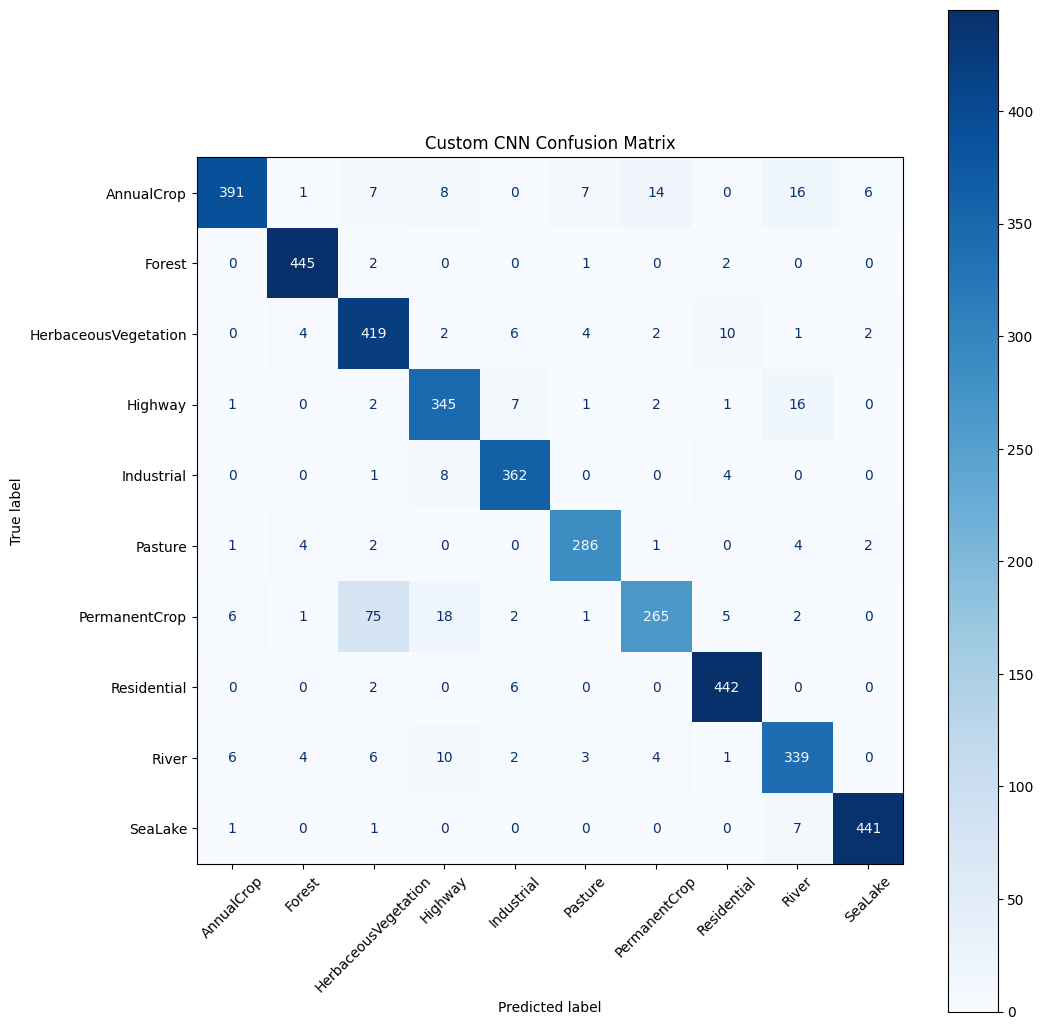

In [23]:
fig, ax = plt.subplots(figsize=(11, 11))

ConfusionMatrixDisplay.from_predictions(
    cnn_true,
    cnn_predictions,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("Custom CNN Confusion Matrix")
plt.tight_layout()
plt.show()

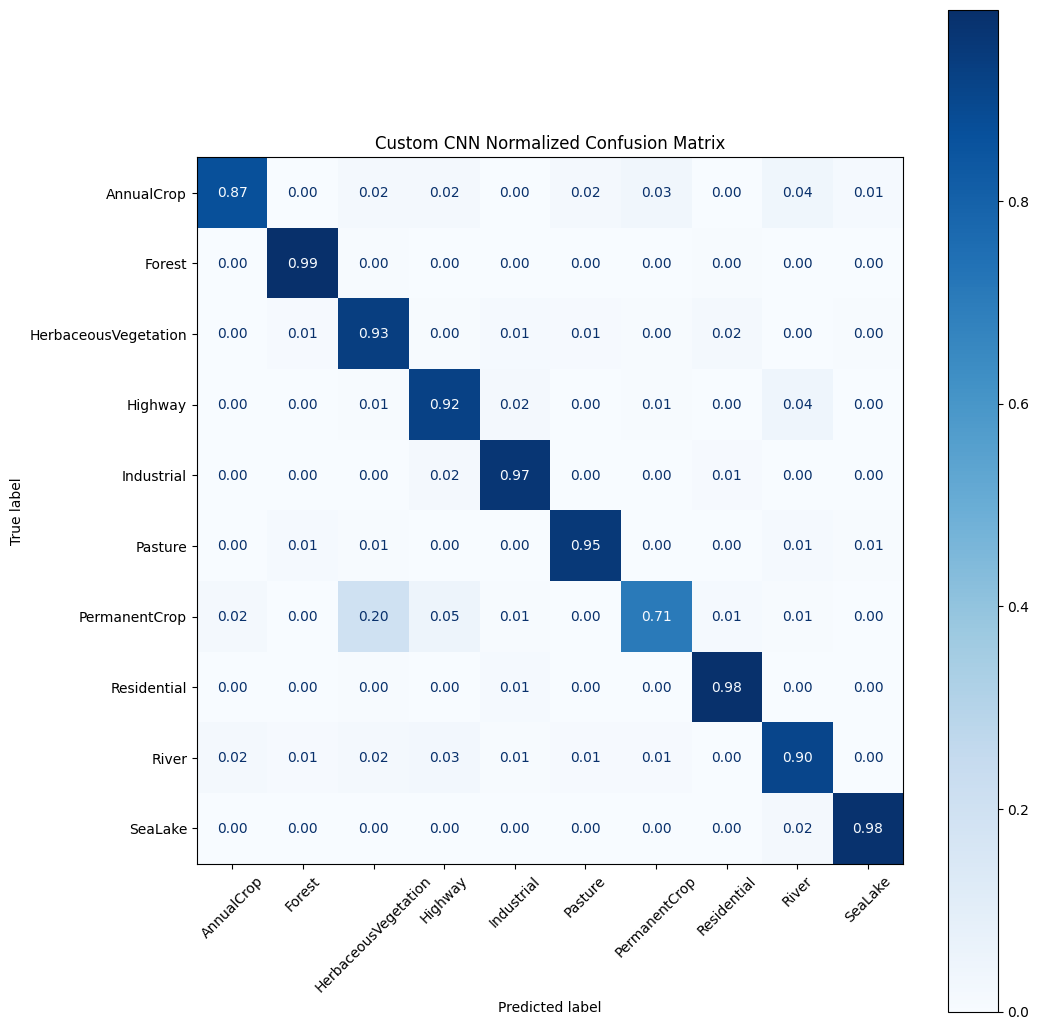

In [24]:
# Normalized confusion matrix shows the proportion of each true class.
fig, ax = plt.subplots(figsize=(11, 11))

ConfusionMatrixDisplay.from_predictions(
    cnn_true,
    cnn_predictions,
    display_labels=class_names,
    xticks_rotation=45,
    cmap="Blues",
    normalize="true",
    values_format=".2f",
    ax=ax
)

plt.title("Custom CNN Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

## 16. Correct and Incorrect Prediction Examples

The next functions display test images with their true class, predicted class,
and prediction confidence.

In [25]:
def show_prediction_examples(
    model,
    data_loader,
    class_names,
    show_errors=False,
    number_of_images=12
):
    model.eval()

    selected_images = []
    selected_true = []
    selected_predictions = []
    selected_confidences = []

    with torch.no_grad():
        for batch_images, batch_labels in data_loader:
            outputs = model(batch_images.to(device))
            probabilities = torch.softmax(outputs, dim=1)
            confidences, predictions = probabilities.max(dim=1)

            predictions = predictions.cpu()
            confidences = confidences.cpu()

            for image, true_label, predicted_label, confidence in zip(
                batch_images,
                batch_labels,
                predictions,
                confidences
            ):
                is_error = true_label.item() != predicted_label.item()

                if is_error == show_errors:
                    selected_images.append(image)
                    selected_true.append(true_label.item())
                    selected_predictions.append(predicted_label.item())
                    selected_confidences.append(confidence.item())

                if len(selected_images) >= number_of_images:
                    break

            if len(selected_images) >= number_of_images:
                break

    if len(selected_images) == 0:
        print("No matching examples were found.")
        return

    columns = 4
    rows = int(np.ceil(len(selected_images) / columns))

    plt.figure(figsize=(16, 4 * rows))

    for i, image in enumerate(selected_images):
        plt.subplot(rows, columns, i + 1)

        display_image = denormalize_image(
            image
        ).permute(1, 2, 0).numpy()

        plt.imshow(display_image)
        plt.title(
            f"True: {class_names[selected_true[i]]}\n"
            f"Pred: {class_names[selected_predictions[i]]}\n"
            f"Confidence: {selected_confidences[i]:.2f}"
        )
        plt.axis("off")

    title = (
        "Misclassified Test Images"
        if show_errors
        else "Correctly Classified Test Images"
    )

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

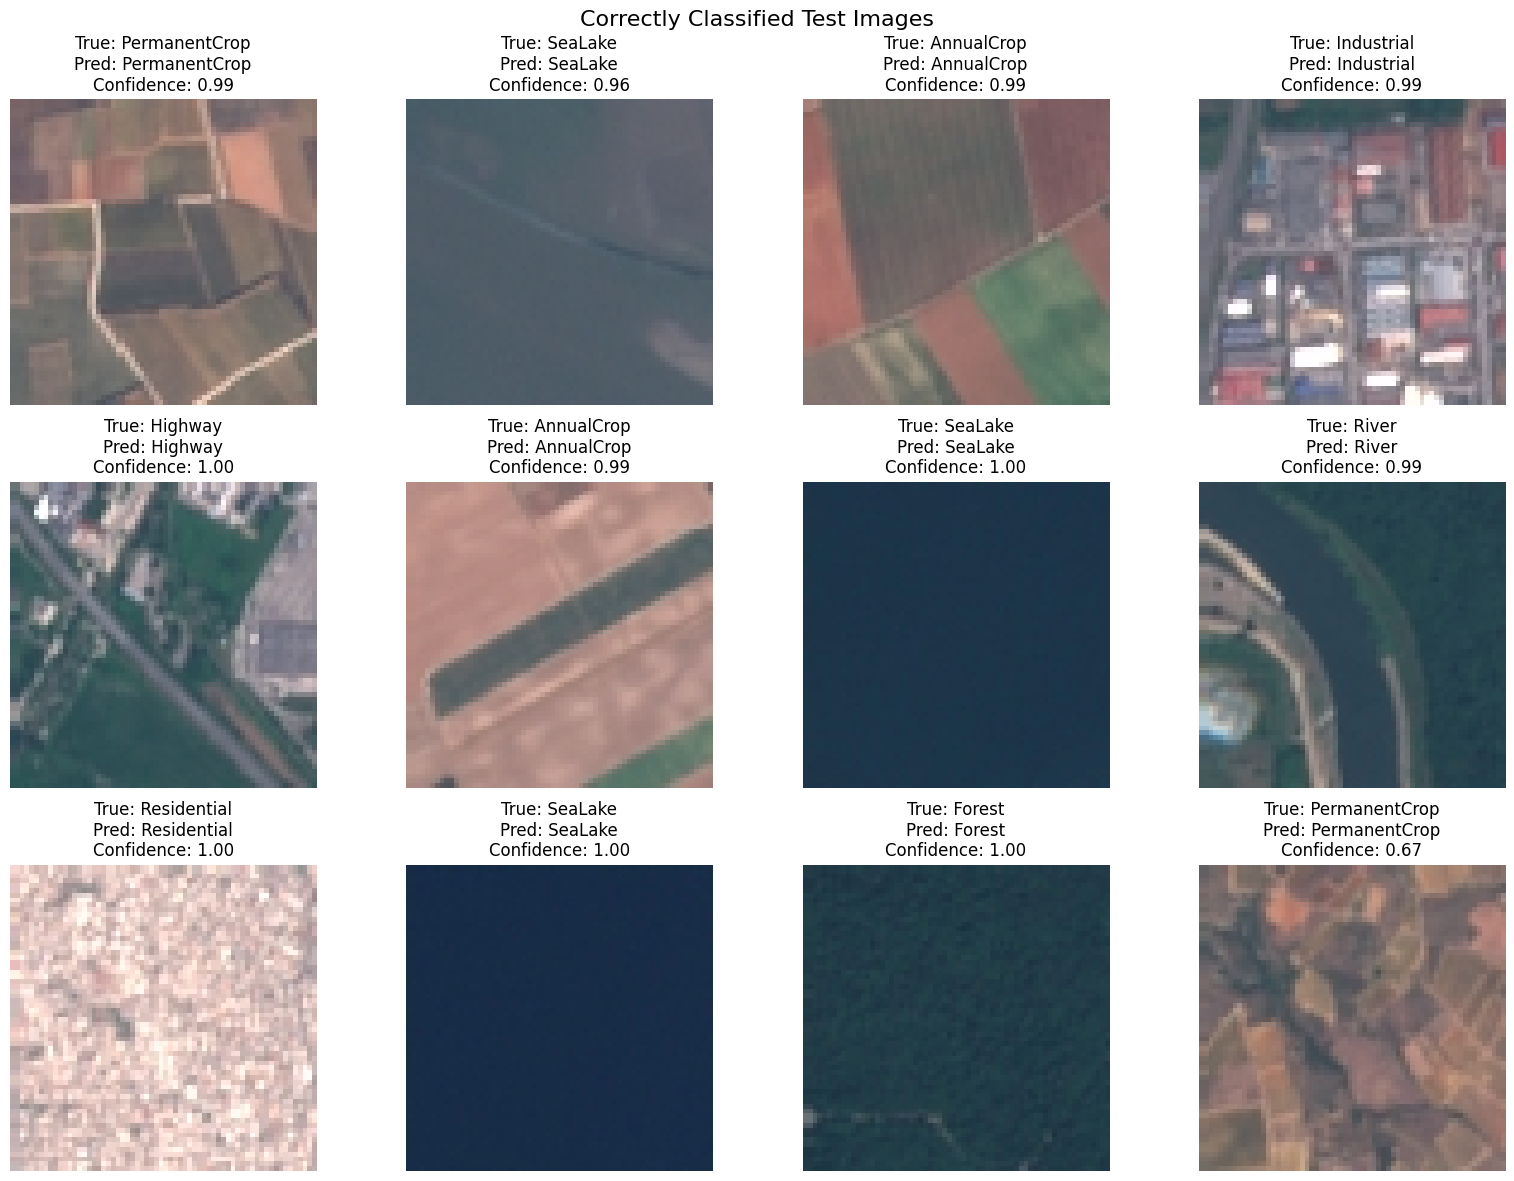

In [26]:
# Correct predictions
show_prediction_examples(
    final_cnn,
    final_test_loader,
    class_names,
    show_errors=False,
    number_of_images=12
)

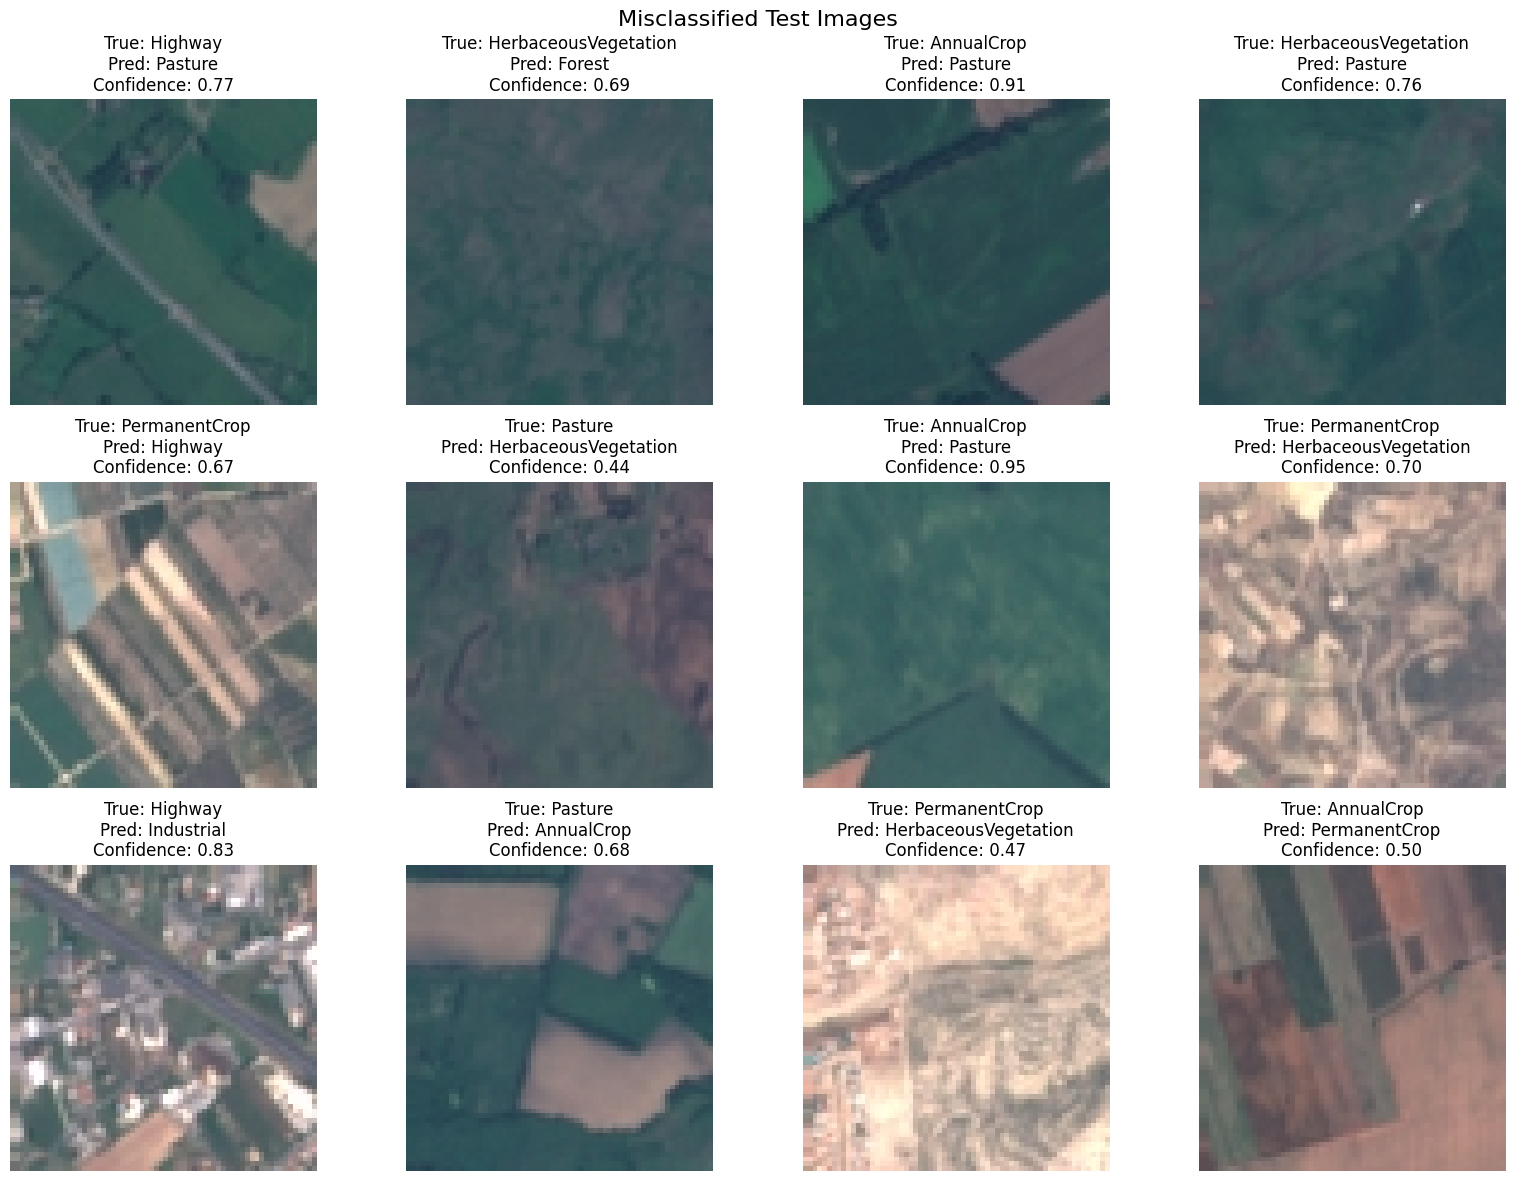

In [27]:
# Misclassified predictions
show_prediction_examples(
    final_cnn,
    final_test_loader,
    class_names,
    show_errors=True,
    number_of_images=12
)

## 17. Misclassification Analysis

Use the confusion matrix and incorrect image examples to complete this section.

Suggested questions:

1. Which two classes were confused most often?
2. Do the confused classes have similar colors, shapes, or textures?
3. Were some images partly covered by another land type?
4. Did low image resolution make the classification more difficult?
5. Did data augmentation improve validation performance?

**Example writing structure**

> The model most often confused __________ with __________. These classes can have
> similar visual patterns because __________. Some incorrect images also contained
> features from more than one land-use class. This suggests that future work could
> use a larger image size, more training data, or additional fine-tuning.

## 18. Model Comparison and Discussion

Complete this section after running both models.

Suggested discussion:

- Which model had the highest test accuracy?
- Which model had the highest weighted F1-score?
- Which model trained faster?
- Did transfer learning improve performance?
- Did either model show overfitting?
- Was the improvement worth the additional model complexity?

**Example writing structure**

> The __________ model achieved the best test accuracy of __________. The custom CNN
> was trained from scratch, while ResNet18 used pretrained image features. The
> comparison shows that __________. However, the custom CNN had the advantage of
> __________.

## 19. Conclusion

Use your real output values to complete the conclusion.

**Suggested conclusion template**

> This project developed a deep learning system for classifying EuroSAT satellite
> images into 10 land-use classes. The data was divided into training, validation,
> and test sets, and augmentation was applied only to training images. Three
> hyperparameter settings were compared before training the final custom CNN.
>
> The final custom CNN achieved a test accuracy of __________ and a weighted F1-score
> of __________. The ResNet18 model achieved __________. The most difficult classes
> were __________ because __________.
>
> Overall, the project showed that CNN models can learn useful visual patterns from
> satellite images. Future improvements could include a larger image resolution,
> more hyperparameter experiments, unfreezing part of ResNet18, testing another
> pretrained model, and using explainability tools such as Grad-CAM.

## 20. Challenges and Lessons Learned

Possible points to discuss:

- Downloading and organizing image data
- Preventing data leakage between splits
- Selecting suitable augmentation
- Choosing learning rate, batch size, and dropout
- Training time on CPU compared with GPU
- Understanding overfitting from the loss curves
- Interpreting the confusion matrix
- Comparing a model trained from scratch with transfer learning

## 21. Suggested GitHub Project Structure

```text
EuroSAT-Capstone/
│
├── EuroSAT_Capstone_Project.ipynb
├── README.md
├── requirements.txt
├── eurosat_outputs/
│   ├── hyperparameter_results.csv
│   ├── model_comparison.csv
│   ├── custom_cnn_classification_report.csv
│   ├── custom_cnn_test_predictions.csv
│   ├── eurosat_custom_cnn.pth
│   └── eurosat_resnet18.pth
└── presentation/
    └── EuroSAT_Presentation.pptx
```

Suggested `requirements.txt`:

```text
torch
torchvision
numpy
pandas
matplotlib
scikit-learn
jupyter
```

## 22. Final Submission Checklist

- [ ] Add student name, student ID, course, and date
- [ ] Run the notebook from top to bottom
- [ ] Set `FAST_MODE = False` for final results
- [ ] Check that all graphs and tables are visible
- [ ] Replace all blank result placeholders with actual values
- [ ] Explain the best hyperparameter experiment
- [ ] Discuss the confusion matrix and misclassifications
- [ ] Compare the custom CNN and ResNet18
- [ ] Save the trained models and CSV result files
- [ ] Upload notebook and supporting files to GitHub
- [ ] Prepare the report and short presentation